**Installing Opendatasets Library**

In [2]:
!pip install opendatasets

**Downloading Dataset of MRI Scans Using Kaggle API**

In [3]:
import os
import opendatasets as od
od.download("https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: sudiponmakal
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset


100%|██████████| 149M/149M [00:00<00:00, 1.58GB/s]

Import Dependencies such as TensorFlow,
TensorFlow->Keras->layers, models
TensorFlow->Keras->Applications->DenseNet101

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.mixed_precision import set_global_policy


In [5]:
set_global_policy("mixed_float16")  # FP16 for speed

IMG_SIZE = (192, 192)
BATCH_SIZE = 32
NUM_CLASSES = 4
EPOCHS = 40

In [6]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/brain-tumor-mri-dataset/Training",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/brain-tumor-mri-dataset/Testing",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

Found 5712 files belonging to 4 classes.
Found 1311 files belonging to 4 classes.


['glioma', 'meningioma', 'notumor', 'pituitary']


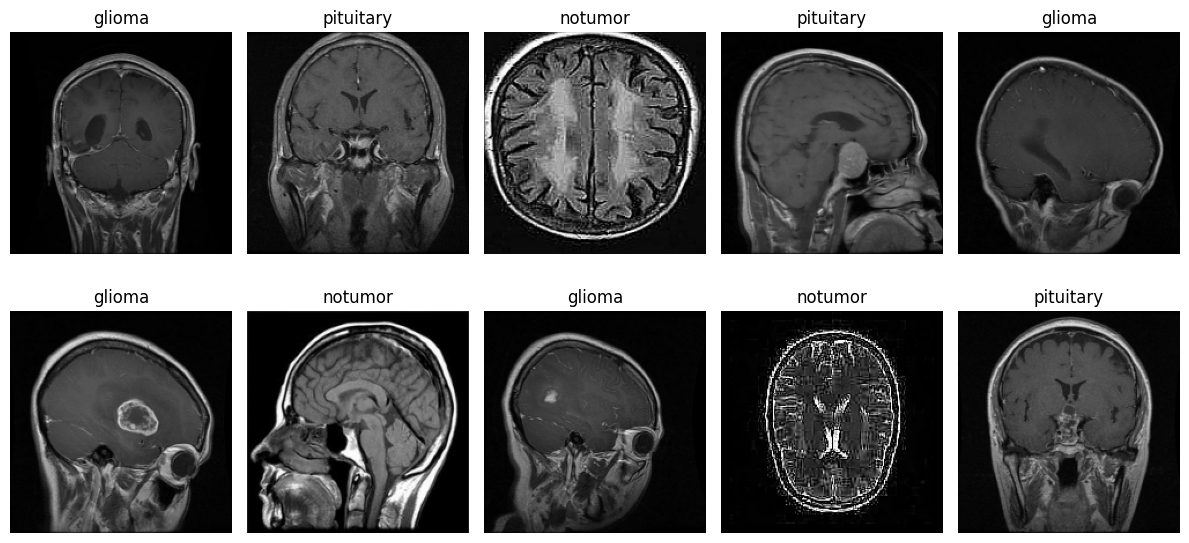

In [7]:
class_names = train_ds.class_names
print(class_names)
import matplotlib.pyplot as plt

class_names = train_ds.class_names

images, labels = next(iter(train_ds))

plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    label = class_names[tf.argmax(labels[i]).numpy()]
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

In [9]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

In [10]:
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=IMG_SIZE + (3,)
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
base_model.trainable = False

In [12]:
inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.densenet.preprocess_input(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.4)(x)


In [13]:
outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    dtype="float32"
)(x)

model = models.Model(inputs, outputs)

In [14]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [15]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.1,
        patience=4,
        min_lr=1e-6
    )
]

In [16]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/40
179/179 ━━━━━━━━━━━━━━━━━━━━ 53s 135ms/step - accuracy: 0.5907 - loss: 1.0187 - val_accuracy: 0.7735 - val_loss: 0.5993 - learning_rate: 1.0000e-04
Epoch 2/40
179/179 ━━━━━━━━━━━━━━━━━━━━ 18s 101ms/step - accuracy: 0.8264 - loss: 0.4804 - val_accuracy: 0.8108 - val_loss: 0.4812 - learning_rate: 1.0000e-04
Epoch 3/40
179/179 ━━━━━━━━━━━━━━━━━━━━ 18s 103ms/step - accuracy: 0.8604 - loss: 0.3670 - val_accuracy: 0.8314 - val_loss: 0.4183 - learning_rate: 1.0000e-04
Epoch 4/40
179/179 ━━━━━━━━━━━━━━━━━━━━ 18s 103ms/step - accuracy: 0.8879 - loss: 0.3155 - val_accuracy: 0.8413 - val_loss: 0.3801 - learning_rate: 1.0000e-04
Epoch 5/40
179/179 ━━━━━━━━━━━━━━━━━━━━ 19s 104ms/step - accuracy: 0.8864 - loss: 0.3056 - val_accuracy: 0.8574 - val_loss: 0.3513 - learning_rate: 1.0000e-04
Epoch 6/40
179/179 ━━━━━━━━━━━━━━━━━━━━ 18s 102ms/step - accuracy: 0.8961 - loss: 0.2790 - val_accuracy: 0.8528 - val_loss: 0.3516 - learning_rate: 1.0000e-04
Epoch 7/40
179/179 ━━━━━━━━━━━━━━━━━━━━ 19s 10

In [17]:
base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

In [18]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [19]:
history_finetune = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 48s 150ms/step - accuracy: 0.9523 - loss: 0.1380 - val_accuracy: 0.9161 - val_loss: 0.2093 - learning_rate: 1.0000e-05
Epoch 2/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 21s 116ms/step - accuracy: 0.9494 - loss: 0.1416 - val_accuracy: 0.9130 - val_loss: 0.2100 - learning_rate: 1.0000e-05
Epoch 3/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 21s 116ms/step - accuracy: 0.9605 - loss: 0.1206 - val_accuracy: 0.9138 - val_loss: 0.2081 - learning_rate: 1.0000e-05
Epoch 4/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 21s 116ms/step - accuracy: 0.9529 - loss: 0.1291 - val_accuracy: 0.9161 - val_loss: 0.2061 - learning_rate: 1.0000e-05
Epoch 5/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 21s 116ms/step - accuracy: 0.9636 - loss: 0.1094 - val_accuracy: 0.9169 - val_loss: 0.2073 - learning_rate: 1.0000e-05
Epoch 6/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 20s 115ms/step - accuracy: 0.9622 - loss: 0.1088 - val_accuracy: 0.9146 - val_loss: 0.2144 - learning_rate: 1.0000e-05
Epoch 7/15
179/179 ━━━━━━━━━━━━━━━━━━━━ 21s 11

In [20]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Final Test Accuracy: {test_acc*100:.4f}%")

41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.9186 - loss: 0.2132
Final Test Accuracy: 93.4401%


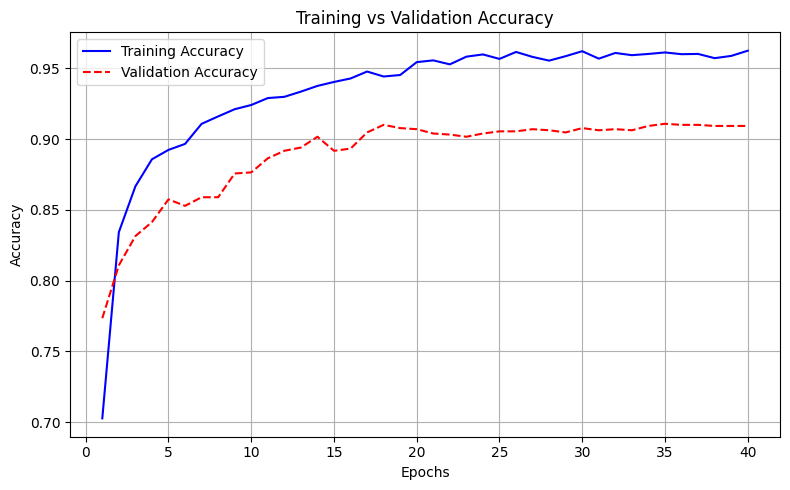

In [21]:
import matplotlib.pyplot as plt

# Get accuracy values
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r--', label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [22]:
model.save("densenet_mri_4class_model.h5")